# פרויקט חיזוי רמת סטרס - KNN

In [37]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


### 1️⃣ ייבוא ספריות

In [38]:

import pandas as pd               # עבודה עם DataFrame (טבלאות)
import numpy as np                # עבודה עם מערכים ומספרים
import matplotlib.pyplot as plt   # ציור גרפים בסיסיים
import seaborn as sns             # גרפים מורכבים כמו heatmaps
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib                     # שמירת מודלים

### 2️⃣ טעינת דאטה

In [39]:
df = pd.read_csv('stress_data.csv')  # טוען את הקובץ ל‑DataFrame
df.head()  # מציג 5 שורות ראשונות כדי לבדוק איך הנתונים נראים

,Sleep_Hours,Work_Hours,Steps,Exercise_Minutes,Stress_Level
0,7.5,10,11064,14,Low
1,6.9,9,11444,58,Medium
2,7.6,8,8413,25,Low
3,8.5,7,8941,40,High
4,6.8,7,11506,44,High


### 3️⃣ בדיקה וניקוי ערכי NaN

In [40]:
df.isna().sum()    # סופר ערכים חסרים בכל עמודה
df = df.dropna()   # מסיר שורות עם ערכים חסרים (למקרה שיש)

### 4️⃣ המרת משתנים קטגוריים למספרים

In [41]:
le = LabelEncoder()
df['Stress_Level'] = le.fit_transform(df['Stress_Level'])  # Low→0, Medium→1, High→2

### 5️⃣ בחירת משתנים (X) ומשתנה מטרה (y)

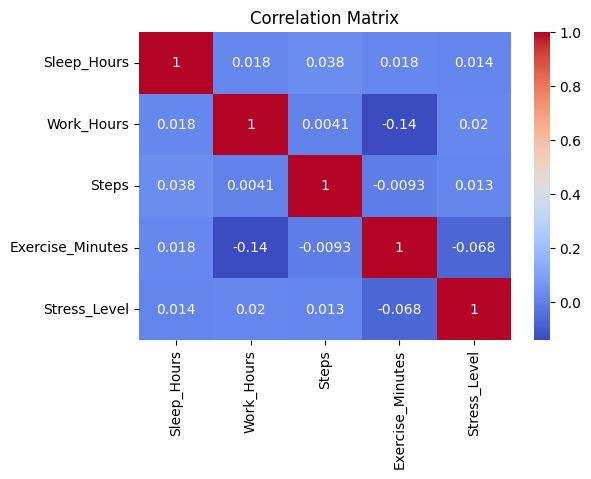

In [42]:
X = df[['Sleep_Hours', 'Work_Hours', 'Steps', 'Exercise_Minutes']]
y = df['Stress_Level']

# בדיקת קורלציה בין המשתנים
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')//1
plt.title("Correlation Matrix")
plt.show()

### 6️⃣ חלוקת הנתונים ל‑Train/Test

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 7️⃣ נרמול (Scaling)

In [44]:
scaler = StandardScaler()//2
X_train_scaled = scaler.fit_transform(X_train)  # fit רק על Train
X_test_scaled = scaler.transform(X_test)        # transform על Test בלבד

### 8️⃣ Hyperparameter Tuning ל-KNN

In [45]:
param_grid = {'n_neighbors': np.arange(1, 21)}  #  בודק K מ-1 עד 20
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best K:", grid.best_params_['n_neighbors'])
knn_best = grid.best_estimator_//3

Best K: 4


### 9️⃣ Cross-Validation

In [46]:
cv_scores = cross_val_score(knn_best, X_train_scaled, y_train, cv=5)
print("Cross-Validation Accuracy:", cv_scores.mean())

Cross-Validation Accuracy: 0.4


### 🔟 הערכה סופית על Test set

In [47]:
y_pred = knn_best.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Test Accuracy: 0.3
Confusion Matrix:
 [[ 3  7  5]
 [ 5 13 11]
 [11 10  5]]
Classification Report:
               precision    recall  f1-score   support

           0       0.16      0.20      0.18        15
           1       0.43      0.45      0.44        29
           2       0.24      0.19      0.21        26

    accuracy                           0.30        70
   macro avg       0.28      0.28      0.28        70
weighted avg       0.30      0.30      0.30        70



### 1️⃣1️⃣ Visualization של Confusion Matrix

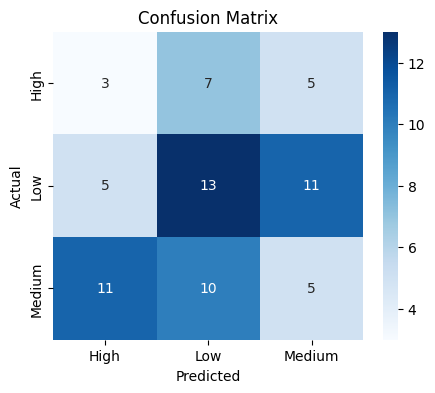

In [48]:
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 1️⃣2️⃣ שמירת המודל וה‑Scaler

In [49]:
joblib.dump(knn_best, 'model.pkl')   # שמירת המודל
joblib.dump(scaler, 'scaler.pkl')    # שמירת הסקיילר

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
